<a href="https://colab.research.google.com/github/Marfall/IT-PROJECT-RISK/blob/main/IT_Project_Risk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Управление IT-проектами на основе данных: прогнозирование успеха, интерпретация рисков и предиктивный мониторинг потерь

**Дипломный проект**

---

## 📌 О проекте

Значительная часть IT-проектов не достигает поставленных целей: сроки сдвигаются, бюджет превышается, продукт не приносит ожидаемой ценности. Как правило, причины становятся очевидны уже после завершения, когда влиять на исход поздно.

Цель проекта — разработать систему поддержки управленческих решений, которая позволяет:
- прогнозировать вероятность успеха проекта на ранней стадии;
- выявлять и интерпретировать ключевые факторы риска;
- отслеживать динамику риска во времени;
- формировать понятные рекомендации для руководителя.

Фактически, это инструмент, который переводит управление проектами с интуитивного уровня на уровень, основанный на данных.

---

## 🧩 Структура системы

| Модуль | Назначение |
|--------|------------|
| **LightGBM + SHAP** | Прогноз риска и объяснение причин |
| **NLP (sentence-transformers)** | Анализ текстов требований |
| **Prophet** | Мониторинг динамики риска по неделям |
| **MLP (PyTorch)** | Сравнение с бустингом для обоснования выбора |
| **Seaborn + Plotly** | Визуализация, ориентированная на бизнес |

---

## 🛠️ Технологический стек

- **Python** — язык реализации
- **pandas, numpy, sklearn** — обработка данных и пайплайны
- **LightGBM** — основная модель
- **SHAP** — интерпретация модели
- **sentence-transformers** — работа с текстом
- **Prophet** — временные ряды
- **PyTorch** — нейросеть для сравнения
- **Seaborn, Plotly** — визуализация
- **Jupyter Notebook** — среда разработки

---

## 📊 Источники данных

- **Project Management Risk Raw** (Kaggle) — 4000 проектов, 51 признак
- **FR_NFR_dataset** (Mendeley) — 6118 требований для NLP-модуля
- **Временной ряд** — синтетический, поскольку в исходных данных отсутствуют временные метки

---

## 📖 Структура работы

1. Введение
2. Данные и EDA
3. Предобработка и пайплайн
4. Прогнозирование успеха (LightGBM)
5. Интерпретация рисков (SHAP)
6. NLP-модуль
7. Временной мониторинг (Prophet)
8. Сравнение с нейросетью
9. Дашборд
10. Выводы и рекомендации

---

## 💰 Бизнес-ценность

- **Прогноз:** проект зелёный / жёлтый / красный
- **Причины:** факторы, которые повышают риск
- **Динамика:** изменение риска по неделям
- **Рекомендации:** управленческие действия для снижения потерь

---

*Автор: [Весновский Александр Андреевич]*  
*Курс: ML Pro, OTUS*  
*Дата: [21.09.2026]*

## 1. Импорт библиотек и настройка окружения

Подключаем базовый стек для анализа данных и визуализации:
- `pandas`, `numpy` — работа с таблицами и массивами;
- `matplotlib`, `seaborn` — графики;
- настраиваем единый стиль визуализации и отображение всех колонок датасета.

Фиксируем seed, чтобы результаты были воспроизводимы при повторных запусках.

In [9]:
# 1: Импорт библиотек, настройка стиля и фиксация seed
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Стиль графиков
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

# Отображение всех колонок в выводе DataFrame
pd.set_option("display.max_columns", None)

# Фиксация seed для воспроизводимости
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

print(f"Seed зафиксирован: {SEED}")

Seed зафиксирован: 42


## 3. Загрузка датасета

На этом шаге подключаем основной датасет — **Project Management Risk Raw** (Kaggle). Датасет содержит 4000 IT-проектов и 51 признак, включая целевую переменную `Risk_Level`.

Логика загрузки:
1. Проверяем наличие файла в стандартных местах (рабочая директория, Google Drive, текущая папка).
2. Если файла нет — скачиваем через Kaggle API.
3. Если API недоступен — оставляем инструкцию для ручной загрузки.

На выходе получаем переменную `DATASET_PATH` с путём к файлу, которую используют следующие ячейки.

In [10]:
# 3: Загрузка датасета Project Management Risk Raw из Google Drive
import os
from pathlib import Path

# Монтируем Google Drive (если ещё не смонтирован)
from google.colab import drive
drive.mount('/content/drive')

# Папка проекта на Drive и имя файла датасета
PROJECT_DIR = Path("/content/drive/MyDrive/ML-PROJECT-RISK-MANAGEMENT-DIPLOMA")
KAGGLE_FILE = "project_risk_raw_dataset.csv"

# Ищем файл датасета в папке проекта
DATASET_PATH = None
if PROJECT_DIR.exists():
    matches = list(PROJECT_DIR.rglob(KAGGLE_FILE))
    if matches:
        DATASET_PATH = str(matches[0])
        print(f"Файл найден: {DATASET_PATH}")
    else:
        print(f"В папке {PROJECT_DIR} файл {KAGGLE_FILE} не найден.")
        print("Содержимое папки:")
        for p in PROJECT_DIR.iterdir():
            print(f"  {p.name}")
else:
    print(f"Папка {PROJECT_DIR} не найдена. Проверьте путь на Google Drive.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Файл найден: /content/drive/MyDrive/ML-PROJECT-RISK-MANAGEMENT-DIPLOMA/project_risk_raw_dataset.csv


## 5. Чтение датасета и первый обзор

Читаем CSV в DataFrame и смотрим базовую структуру:
- `head()` — как выглядят первые строки, какие есть колонки;
- `shape` — размер таблицы (строки × столбцы);
- `info()` — типы данных и количество непустых значений (сразу видно, где пропуски);
- `describe()` — основные статистики по числовым признакам: среднее, минимум, максимум, квартили.

На этом шаге цель — понять, с чем вообще работаем, до любых преобразований.

In [11]:
# 6: Чтение CSV и первичный обзор структуры данных
df = pd.read_csv(DATASET_PATH)

# Первые строки
print("Первые 5 строк:")
display(df.head())

# Размер таблицы
print(f"\nРазмер: {df.shape[0]} строк, {df.shape[1]} колонок")

# Типы данных и пропуски — первые 15 колонок, чтобы не заваливать вывод
print("\nСтруктура (первые 15 колонок):")
df.iloc[:, :15].info()

# Описательные статистики — первые 15 колонок
print("\nОписательные статистики (первые 15 колонок):")
display(df.iloc[:, :15].describe().T)

Первые 5 строк:


,Project_ID,Project_Type,Team_Size,Project_Budget_USD,Estimated_Timeline_Months,Complexity_Score,Stakeholder_Count,Methodology_Used,Team_Experience_Level,Past_Similar_Projects,External_Dependencies_Count,Change_Request_Frequency,Project_Phase,Requirement_Stability,Team_Turnover_Rate,Vendor_Reliability_Score,Historical_Risk_Incidents,Communication_Frequency,Regulatory_Compliance_Level,Technology_Familiarity,Geographical_Distribution,Stakeholder_Engagement_Level,Schedule_Pressure,Budget_Utilization_Rate,Executive_Sponsorship,Funding_Source,Market_Volatility,Integration_Complexity,Resource_Availability,Priority_Level,Organizational_Change_Frequency,Cross_Functional_Dependencies,Previous_Delivery_Success_Rate,Technical_Debt_Level,Project_Manager_Experience,Org_Process_Maturity,Data_Security_Requirements,Key_Stakeholder_Availability,Tech_Environment_Stability,Contract_Type,Resource_Contention_Level,Industry_Volatility,Client_Experience_Level,Change_Control_Maturity,Risk_Management_Maturity,Team_Colocation,Documentation_Quality,Project_Start_Month,Current_Phase_Duration_Months,Seasonal_Risk_Factor,Risk_Level
0,PROJ_0001,Construction,32,1526276.55,32,9.70,16,Waterfall,Senior,3,3,1.05,Planning,Moderate,0.16,0.84,2,1.90,Medium,Expert,4,Medium,0.0,0.82,Moderate,Government,0.55,2.66,0.98,Medium,0.29,6,0.80,0.00,Mid-level PM,Managed,Medium,Limited,NaN,Time & Materials,High,Extreme,First-time,Basic,Basic,Fully Colocated,Good,10,5,1.0,High
1,PROJ_0002,Manufacturing,2,390790.15,9,2.72,9,Kanban,Mixed,0,2,2.61,Execution,Moderate,0.42,0.79,2,2.65,High,Familiar,5,Excellent,0.0,0.76,Weak,External,0.29,2.45,0.95,Low,0.50,3,0.73,0.00,Mid-level PM,Optimizing,Low,Excellent,NaN,Cost-Plus,Low,Stable,Occasional,Advanced,Formal,Fully Remote,Poor,9,3,1.0,Low
2,PROJ_0003,Manufacturing,2,246674.76,6,2.04,7,Agile,Mixed,1,0,0.83,Initiation,Stable,0.55,0.89,2,1.87,Medium,Familiar,3,Excellent,0.0,1.17,Strong,Internal,0.15,5.57,0.79,High,2.71,2,0.91,0.00,Mid-level PM,Ad-hoc,Medium,Moderate,NaN,Cost-Plus,High,Stable,Regular,NaN,NaN,Hybrid,Good,5,1,1.0,Medium
3,PROJ_0004,IT,12,1427830.63,17,7.54,16,Scrum,Mixed,0,5,2.42,Initiation,Moderate,0.33,0.84,1,1.36,Low,Familiar,5,Medium,0.1,0.73,Moderate,Mixed,0.74,7.49,0.52,Critical,0.74,5,0.71,0.43,Certified PM,Managed,Strict,Good,Mixed,Hybrid,High,Extreme,Strategic,Formal,Basic,Hybrid,Basic,12,6,1.1,High
4,PROJ_0005,Construction,24,1696746.64,24,6.68,17,Hybrid,Junior,0,2,0.16,Execution,Stable,0.36,0.86,1,1.02,Critical,Expert,2,Low,0.0,0.60,Moderate,Government,0.19,1.64,0.58,Medium,0.56,6,0.83,0.00,Certified PM,Defined,Medium,Moderate,NaN,Cost-Plus,High,Moderate,Occasional,Basic,NaN,Partially Colocated,Basic,9,6,1.0,High



Размер: 4000 строк, 51 колонок

Структура (первые 15 колонок):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Project_ID                   4000 non-null   object 
 1   Project_Type                 4000 non-null   object 
 2   Team_Size                    4000 non-null   int64  
 3   Project_Budget_USD           4000 non-null   float64
 4   Estimated_Timeline_Months    4000 non-null   int64  
 5   Complexity_Score             4000 non-null   float64
 6   Stakeholder_Count            4000 non-null   int64  
 7   Methodology_Used             4000 non-null   object 
 8   Team_Experience_Level        4000 non-null   object 
 9   Past_Similar_Projects        4000 non-null   int64  
 10  External_Dependencies_Count  4000 non-null   int64  
 11  Change_Request_Frequency     4000 non-null   float64
 12  Project_Phas

,count,mean,std,min,25%,50%,75%,max
Team_Size,4000.0,1.538825e+01,9.220969,2.00,9.000,13.000,2.000000e+01,50.00
Project_Budget_USD,4000.0,1.143032e+06,590878.115350,159355.55,692532.915,1007471.805,1.475870e+06,3768354.37
Estimated_Timeline_Months,4000.0,1.714775e+01,6.926609,2.00,12.000,17.000,2.200000e+01,36.00
Complexity_Score,4000.0,6.192525e+00,2.212538,1.62,4.460,6.015,7.862500e+00,10.00
Stakeholder_Count,4000.0,1.113050e+01,4.425875,2.00,8.000,10.000,1.400000e+01,29.00
Past_Similar_Projects,4000.0,1.973750e+00,1.750093,0.00,1.000,2.000,3.000000e+00,10.00
External_Dependencies_Count,4000.0,3.127750e+00,1.609216,0.00,2.000,3.000,4.000000e+00,7.00
Change_Request_Frequency,4000.0,1.638080e+00,1.170451,0.01,0.760,1.370,2.230000e+00,8.84
Team_Turnover_Rate,4000.0,2.927250e-01,0.166546,0.00,0.160,0.270,4.000000e-01,0.85


## 7. Первичный обзор данных

**Что видим:**
- 4000 строк, 51 колонка — достаточно для обучения, но без избытка.
- Целевая переменная — `Risk_Level` (High / Medium / Low). Задача — классификация.
- Признаки смешанные: числовые (бюджет, сроки, сложность), категориальные (тип проекта, методология, фаза), порядковые (уровень опыта).
- В первых 15 колонках пропусков нет. В остальных (например, `Tech_Environment_Stability`) встречаются NaN — проверим отдельно.
- `Project_ID` — уникальный идентификатор, для модели не нужен. Удалим.

**Что это значит для проекта:**
- Данные подходят под задачу: есть цель и богатый набор признаков.
- Категориальные признаки потребуют кодирования (One-Hot или Target Encoding).
- Числовые признаки в разном масштабе. Для LightGBM масштабирование не критично, для MLP — обязательно.
- Пропуски есть, но их немного — обработаем на этапе предобработки.

**Следующий шаг:**
1. Проверить пропуски по всем 51 колонке.
2. Посмотреть распределение `Risk_Level` — есть ли дисбаланс классов.
3. Проверить дубликаты и аномалии.

## 7. EDA: исследовательский анализ

Я разбиваю EDA на шесть пунктов и иду по порядку:

1. **Пропуски** — смотрю, сколько, где и какая доля. Решаю, как обрабатывать каждую колонку.
2. **Целевая переменная `Risk_Level`** — проверяю распределение классов, оцениваю дисбаланс.
3. **Дубликаты** — ищу полные совпадения строк.
4. **Числовые признаки** — смотрю распределения, выбросы, корреляции.
5. **Категориальные признаки** — считаю уникальные значения, решаю, как кодировать.
6. **Выводы и решения по EDA** — фиксирую, что оставить, что удалить, что преобразовать перед подачей в модель. Здесь же формулирую конкретные шаги для этапа предобработки.

### 7.1. Пропуски

Считаю пропуски по каждой колонке — в штуках и в процентах, сортирую по убыванию.

Смотрю топ-15 по доле пропусков, чтобы понять, с чем вообще имею дело. Дальше решаю по каждой колонке: где-то пропусков мало — заполню медианой, где-то колонка вообще лишняя, а в числовых признаках для LightGBM часть пропусков можно не трогать — модель работает с ними напрямую.

Стратегию выберу, когда увижу распределение.

Колонок с пропусками: 3 из 51
Всего пропущенных значений: 4190

Топ-15 по количеству пропусков:
                            Пропуски  Доля, %
Tech_Environment_Stability      2619    65.48
Risk_Management_Maturity         791    19.78
Change_Control_Maturity          780    19.50


/tmp/ipykernel_1820/3660290806.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_missing["Доля, %"], y=top_missing.index, palette="viridis")


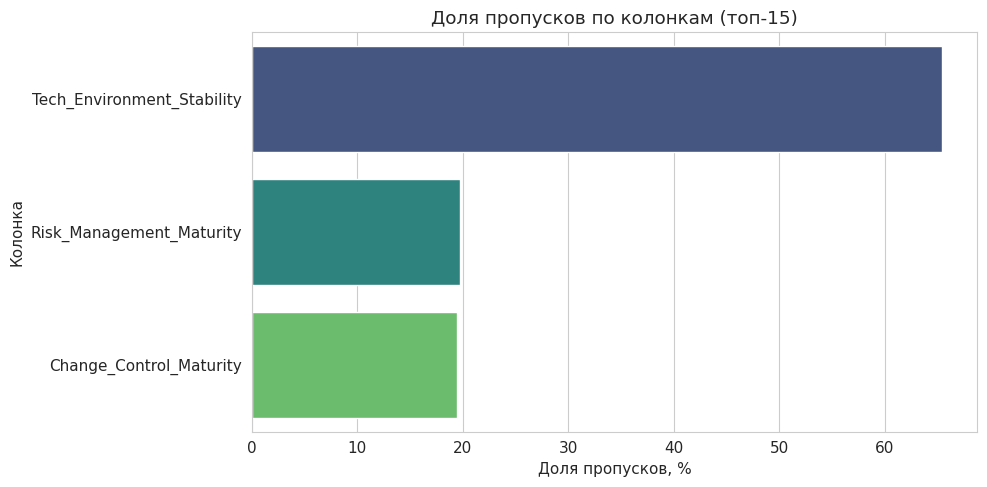

In [12]:
# 7.1: EDA — пропуски
missing_count = df.isna().sum()
missing_pct = (missing_count / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    "Пропуски": missing_count,
    "Доля, %": missing_pct
}).sort_values("Пропуски", ascending=False)

# Отбрасываю колонки без пропусков — они не интересны
missing_df = missing_df[missing_df["Пропуски"] > 0]

print(f"Колонок с пропусками: {len(missing_df)} из {df.shape[1]}")
print(f"Всего пропущенных значений: {missing_count.sum()}")

if len(missing_df) > 0:
    print("\nТоп-15 по количеству пропусков:")
    print(missing_df.head(15).to_string())

    # Топ-15 колонок по доле пропусков
    top_missing = missing_df.head(15)
    plt.figure(figsize=(10, 5))
    sns.barplot(x=top_missing["Доля, %"], y=top_missing.index, palette="viridis")
    plt.title("Доля пропусков по колонкам (топ-15)")
    plt.xlabel("Доля пропусков, %")
    plt.ylabel("Колонка")
    plt.tight_layout()
    plt.show()
    plt.close("all")
else:
    print("Пропусков в датасете нет.")

### 7.1. Пропуски — выводы и решения

Пропуски есть только в 3 колонках из 51. Это немного, но одна колонка требует особого внимания.

**Что я вижу:**
- `Tech_Environment_Stability` — 65.5% пропусков. Это критично: больше половины данных отсутствует.
- `Risk_Management_Maturity` — 19.8%.
- `Change_Control_Maturity` — 19.5%.

**Мои решения:**
- `Tech_Environment_Stability` — удаляю. При 65% пропусков заполнение исказит данные, а польза от признака сомнительна. LightGBM умеет работать с пропусками, но не когда их больше половины.
- `Risk_Management_Maturity` и `Change_Control_Maturity` — оставляю. Пропусков меньше 20%, и эти признаки напрямую связаны с управлением рисками. Оставлю как есть: LightGBM обработает пропуски автоматически. Если буду использовать MLP — заполню модой или отдельной категорией «Unknown».

### 7.2. Целевая переменная Risk_Level

Смотрю, сколько проектов попадает в каждый класс риска и какую долю они занимают.

Если один класс заметно больше остальных — это дисбаланс. Тогда при обучении стоит добавить `class_weight` или делать стратифицированное разбиение, иначе модель будет предсказывать большинство.

Заодно проверяю, задача бинарная или многоклассовая — от этого зависят метрики и выбор модели.

Распределение Risk_Level:
            Количество  Доля, %
Risk_Level                     
Medium            1396    34.90
High              1036    25.90
Low                806    20.15
Critical           762    19.05


/tmp/ipykernel_1820/3247713639.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Risk_Level", palette="viridis", order=target_counts.index)


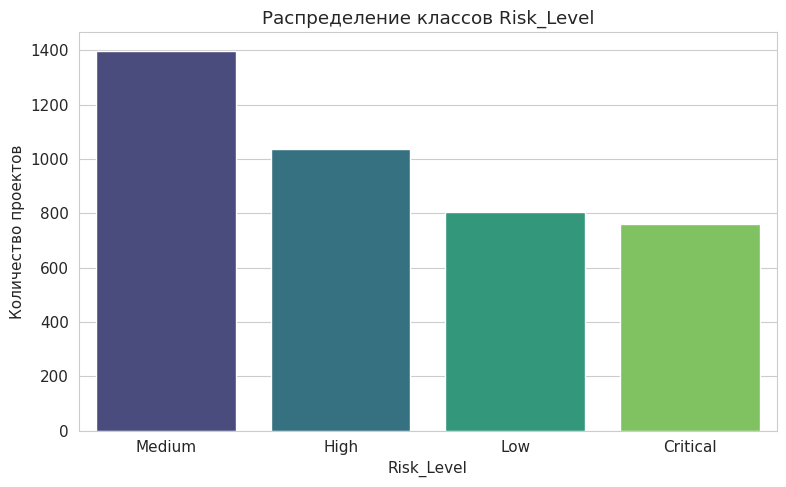

In [13]:
# 11: EDA — распределение целевой переменной
target_counts = df["Risk_Level"].value_counts()
target_pct = (target_counts / len(df) * 100).round(2)

target_df = pd.DataFrame({
    "Количество": target_counts,
    "Доля, %": target_pct
})
print("Распределение Risk_Level:")
print(target_df.to_string())

# Соотношение классов — оценка дисбаланса
if len(target_counts) == 2:
    ratio = target_counts.max() / target_counts.min()
    print(f"\nСоотношение классов: {ratio:.2f}:1")

# График распределения
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Risk_Level", palette="viridis", order=target_counts.index)
plt.title("Распределение классов Risk_Level")
plt.xlabel("Risk_Level")
plt.ylabel("Количество проектов")
plt.tight_layout()
plt.show()
plt.close("all")

### 7.2. Целевая переменная `Risk_Level` — выводы и решения

**Что я вижу:**
- Четыре класса: Medium (34.9%), High (25.9%), Low (20.2%), Critical (19.1%).
- Дисбаланс умеренный: самый частый класс (Medium) встречается в 1.8 раза чаще самого редкого (Critical).
- Задача — **многоклассовая классификация**, а не бинарная. Это важно для выбора метрик и стратегии обучения.

**Что это значит для проекта:**
- Accuracy здесь не подойдёт как основная метрика: модель, которая всегда предсказывает Medium, получит 35% accuracy, но не будет полезна.
- Для оценки буду использовать **F1-macro** (учитывает все классы одинаково) и **ROC-AUC OvR** (для многоклассовой задачи).
- Дисбаланс умеренный, поэтому тяжёлые методы балансировки (SMOTE и т.п.) скорее всего не понадобятся. Но проверю: если модель будет игнорировать класс Critical, применю взвешивание классов (`class_weight`).
- Класс **Critical** — самый важный для бизнеса: это проекты с высоким риском провала. Нужно убедиться, что модель их ловит, а не «прячет» за Medium.

**Мои решения:**
- Оставляю все четыре класса.
- Основная метрика — F1-macro.
- При обучении проверю важность класса Critical и при необходимости добавлю веса.

### 7.3. Дубликаты

Проверяю, есть ли полные дубликаты строк — когда все колонки совпадают.

Если дубликатов много, они искажают распределение и могут утечь между train и test: модель увидит один и тот же пример и в обучении, и в проверке. Тогда метрики будут завышены.

Если дубликатов мало (единицы) — можно просто удалить. Если много — стоит разобраться, откуда они взялись.

In [14]:
# 7.3: EDA — дубликаты
dup_count = df.duplicated().sum()
dup_pct = dup_count / len(df) * 100

print(f"Полных дубликатов строк: {dup_count} ({dup_pct:.2f}%)")

# Если дубликаты есть — смотрю пару примеров, чтобы понять природу
if dup_count > 0:
    dup_examples = df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist()).head(6)
    print("\nПримеры дублирующихся строк (первые 6):")
    display(dup_examples)

Полных дубликатов строк: 0 (0.00%)


### 7.3. Дубликаты — выводы и решения

**Что я вижу:**
- Полных дубликатов строк — 0.

**Мои решения:**
- Ничего удалять не нужно.
- Перехожу к анализу числовых признаков.

### 7.4. Числовые признаки

Смотрю список числовых колонок, строю гистограммы для первых девяти — чтобы охватить обзор, не раздувая вывод.

Дальше — корреляционная матрица. Она показывает, какие признаки связаны между собой. Если два признака коррелируют сильно (0.9+), один из них, скорее всего, лишний — это снижает интерпретируемость и может мешать линейным моделям. LightGBM к этому устойчив, но для SHAP-анализа дубли лучше убрать.

Отдельно посмотрю на выбросы — boxplot'ы помогут понять, есть ли хвосты, которые стоит резать.

Числовых колонок: 25
Список: ['Team_Size', 'Project_Budget_USD', 'Estimated_Timeline_Months', 'Complexity_Score', 'Stakeholder_Count', 'Past_Similar_Projects', 'External_Dependencies_Count', 'Change_Request_Frequency', 'Team_Turnover_Rate', 'Vendor_Reliability_Score', 'Historical_Risk_Incidents', 'Communication_Frequency', 'Geographical_Distribution', 'Schedule_Pressure', 'Budget_Utilization_Rate', 'Market_Volatility', 'Integration_Complexity', 'Resource_Availability', 'Organizational_Change_Frequency', 'Cross_Functional_Dependencies', 'Previous_Delivery_Success_Rate', 'Technical_Debt_Level', 'Project_Start_Month', 'Current_Phase_Duration_Months', 'Seasonal_Risk_Factor']

Сводка по числовым признакам (первые 9):
                              count         mean         std        min         25%          50%          75%         max   skew   kurt
Team_Size                    4000.0       15.388       9.221       2.00       9.000       13.000       20.000       50.00  1.138  1.185
Projec

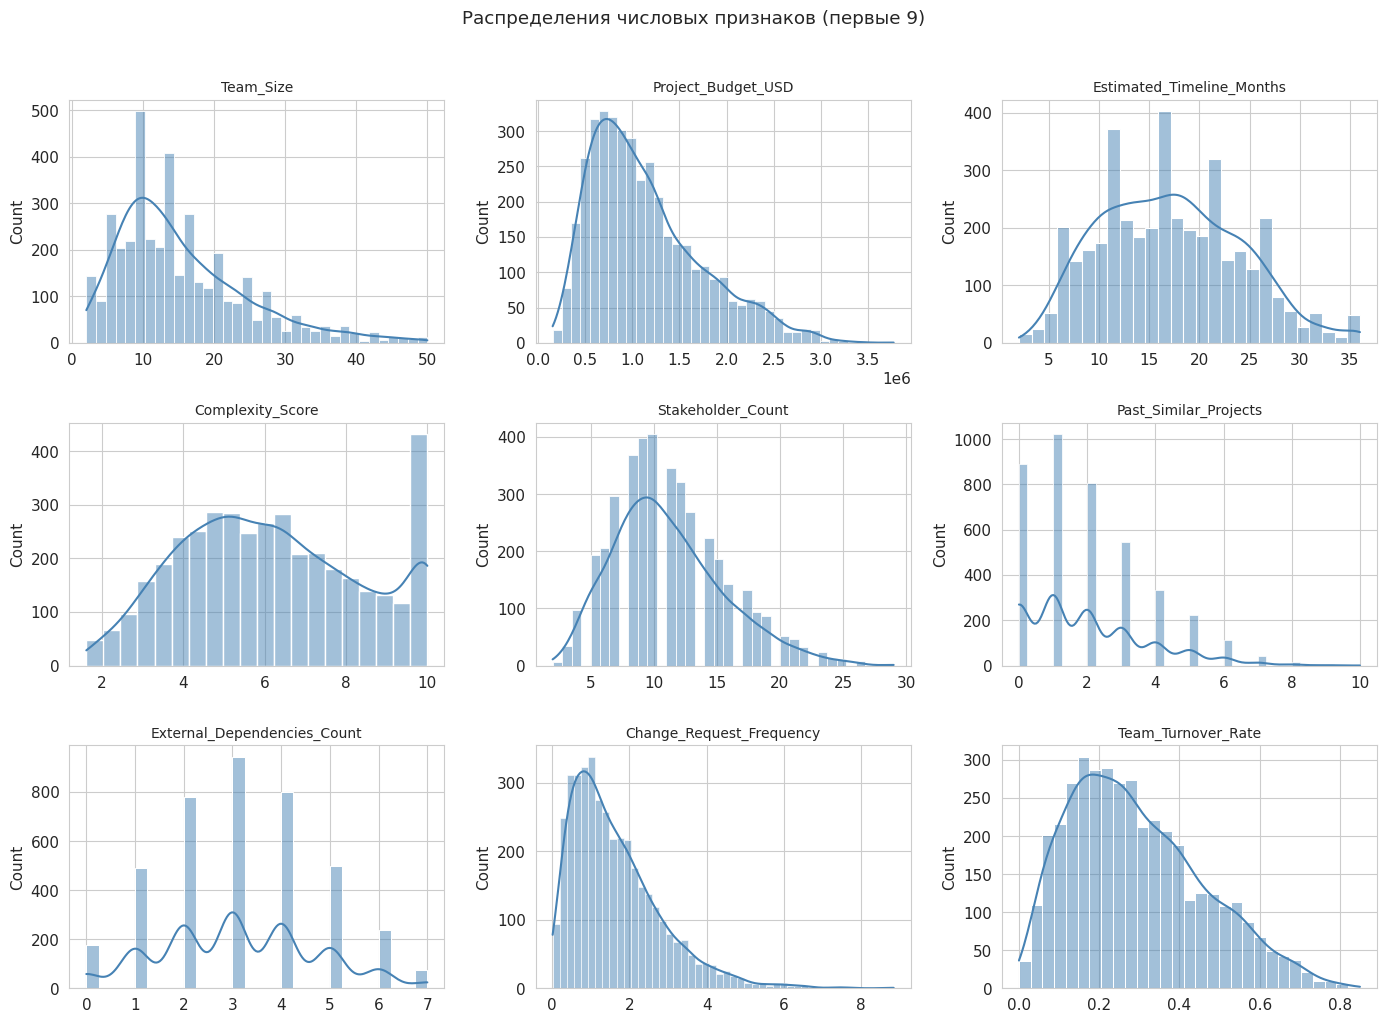

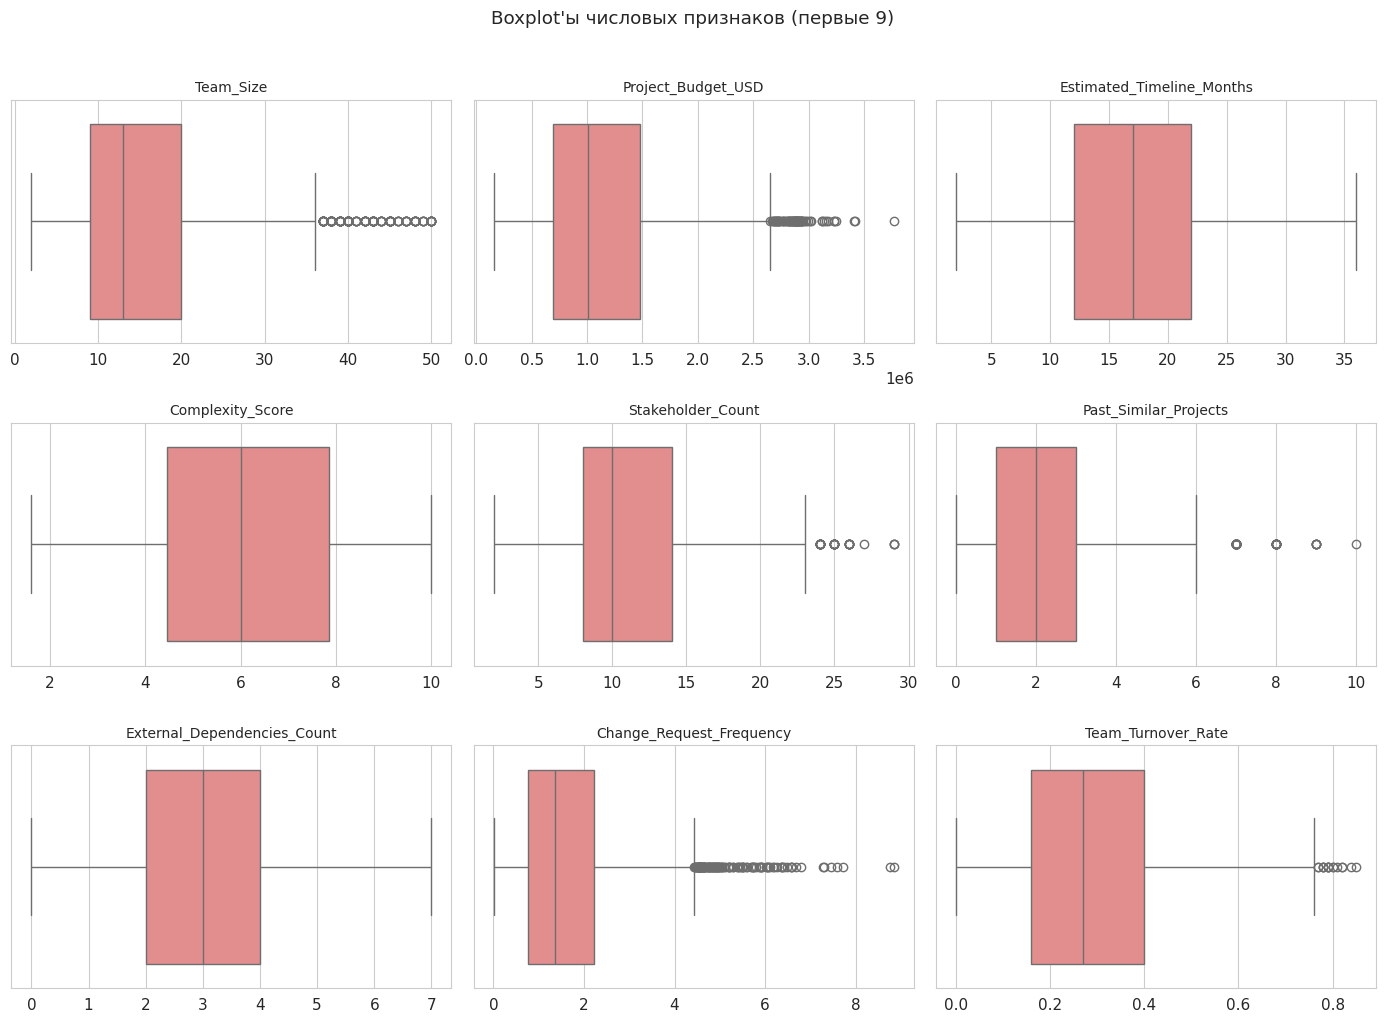

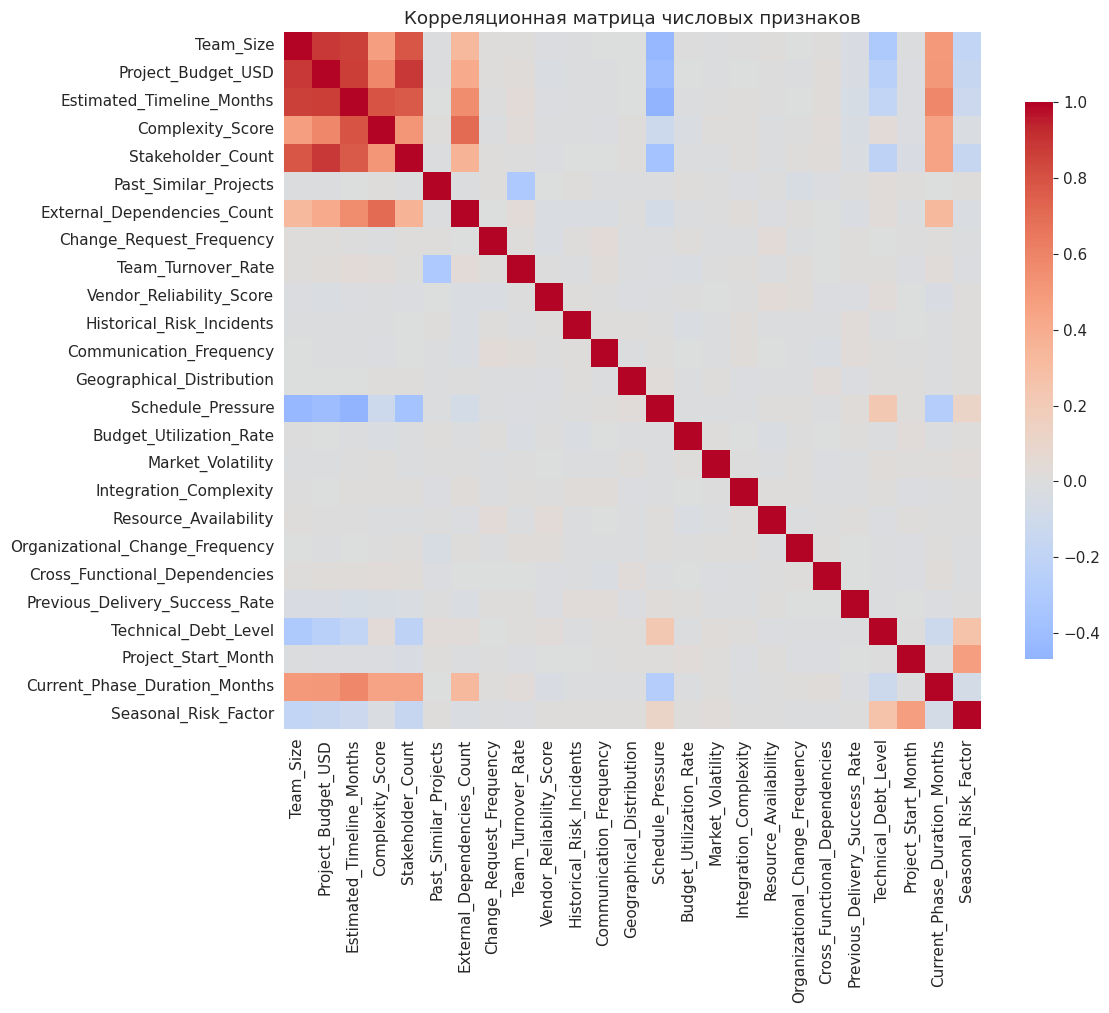


Пары признаков с |r| > 0.7:
                Признак 1                   Признак 2  Корреляция
       Project_Budget_USD           Stakeholder_Count       0.889
                Team_Size          Project_Budget_USD       0.886
       Project_Budget_USD   Estimated_Timeline_Months       0.864
                Team_Size   Estimated_Timeline_Months       0.862
Estimated_Timeline_Months            Complexity_Score       0.793
                Team_Size           Stakeholder_Count       0.788
Estimated_Timeline_Months           Stakeholder_Count       0.770
         Complexity_Score External_Dependencies_Count       0.704


In [17]:
# 7.4: EDA — числовые признаки
num_cols = df.select_dtypes(include=np.number).columns.tolist()
print(f"Числовых колонок: {len(num_cols)}")
print(f"Список: {num_cols}")

n_show = min(9, len(num_cols))
show_cols = num_cols[:n_show]

# Числовая сводка по первым 9 признакам — чтобы читать графики не только глазами
stats_df = df[show_cols].describe().T
stats_df["skew"] = df[show_cols].skew()
stats_df["kurt"] = df[show_cols].kurt()
stats_df = stats_df[["count", "mean", "std", "min", "25%", "50%", "75%", "max", "skew", "kurt"]].round(3)
print("\nСводка по числовым признакам (первые 9):")
print(stats_df.to_string())

# Гистограммы — первые 9 признаков
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for ax, col in zip(axes.flatten(), show_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=ax, color="steelblue")
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")
for ax in axes.flatten()[n_show:]:
    ax.axis("off")
plt.suptitle("Распределения числовых признаков (первые 9)", y=1.02)
plt.tight_layout()
plt.show()
plt.close("all")

# Boxplot'ы — те же признаки, оценка выбросов
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for ax, col in zip(axes.flatten(), show_cols):
    sns.boxplot(x=df[col].dropna(), ax=ax, color="lightcoral")
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")
for ax in axes.flatten()[n_show:]:
    ax.axis("off")
plt.suptitle("Boxplot'ы числовых признаков (первые 9)", y=1.02)
plt.tight_layout()
plt.show()
plt.close("all")

# Корреляционная матрица + таблица сильных пар
if len(num_cols) > 1:
    corr = df[num_cols].corr()

    plt.figure(figsize=(12, 10))
    sns.heatmap(corr, cmap="coolwarm", center=0, annot=False,
                square=True, cbar_kws={"shrink": 0.8})
    plt.title("Корреляционная матрица числовых признаков")
    plt.tight_layout()
    plt.show()
    plt.close("all")

    # Числовая сводка: пары признаков с корреляцией выше 0.7
    corr_pairs = (
        corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
            .stack()
            .reset_index()
    )
    corr_pairs.columns = ["Признак 1", "Признак 2", "Корреляция"]
    corr_pairs["|r|"] = corr_pairs["Корреляция"].abs()
    strong_pairs = corr_pairs[corr_pairs["|r|"] > 0.7].sort_values("|r|", ascending=False)

    print("\nПары признаков с |r| > 0.7:")
    if len(strong_pairs) > 0:
        print(strong_pairs[["Признак 1", "Признак 2", "Корреляция"]].round(3).to_string(index=False))
    else:
        print("Сильных корреляций (> 0.7) не найдено.")

### 7.4. Числовые признаки

**Что я построил:**
- Сводную таблицу статистик по первым 9 числовым признакам: среднее, стандартное отклонение, квартили, асимметрия (skew), эксцесс (kurt).
- Гистограммы с ядерной оценкой плотности (KDE) для первых 9 признаков — чтобы увидеть форму распределения.
- Боксплоты для тех же признаков — чтобы оценить выбросы.
- Тепловую карту корреляций по всем 25 числовым признакам.
- Отдельную таблицу пар признаков с сильной корреляцией (|r| > 0.7).

**Что я вижу на гистограммах:**
- Большинство признаков распределены близко к нормальному: `Team_Size`, `Project_Budget_USD`, `Estimated_Timeline_Months`, `Complexity_Score`.
- Выраженная правосторонняя асимметрия у `Change_Request_Frequency` (skew = 1.35) и `Team_Size` (skew = 1.14) — есть длинный хвост больших значений.
- `Project_Budget_USD` (skew = 0.95) также смещён вправо: большинство проектов дешевле среднего, но есть дорогие выбросы.

**Что я вижу на боксплотах:**
- Выбросы подтверждаются: например, у `Project_Budget_USD` — несколько проектов выше 3M при 75-м перцентиле на 1.47M.
- У `Team_Size` есть проекты с командами до 50 человек, тогда как медиана — 13.
- Это ожидаемо для реальных данных: крупные проекты встречаются реже мелких.

**Что я вижу на тепловой карте:**
- Чётко выделяется блок сильно связанных признаков: `Project_Budget_USD`, `Team_Size`, `Estimated_Timeline_Months`, `Stakeholder_Count`, `Complexity_Score`, `External_Dependencies_Count`.
- Корреляции внутри блока — от 0.70 до 0.89. Это классическая мультиколлинеарность: крупные проекты одновременно дорогие, длинные и сложные.
- Остальные признаки слабо коррелируют между собой — они несут независимую информацию.

**Что это значит для проекта:**
- Мультиколлинеарность не мешает LightGBM: деревья выбирают наиболее информативный признак из группы. Но при интерпретации через SHAP вклад может «размазаться» между связанными признаками. Учту это на этапе анализа важности.
- Асимметрия и выбросы для LightGBM не критичны — деревья работают с рангами, а не с абсолютными значениями. Для MLP проверю после масштабирования.

**Мои решения:**
- Ничего не удаляю на этом этапе.
- К интерпретации вернусь после обучения модели: если SHAP покажет дублирование, рассмотрю удаление одного признака из сильно связанной пары.

### 7.5. Категориальные признаки

Смотрю, сколько категориальных колонок и сколько уникальных значений в каждой. Это ключевой момент для выбора кодирования.

Логика простая:
- мало уникальных (до 10–15) — one-hot или ordinal, разницы почти нет;
- много уникальных (десятки и сотни) — one-hot раздует матрицу, лучше target encoding или оставить как категорию для LightGBM (он умеет работать с категориями нативно);
- если уникальных почти столько же, сколько строк — это ID или текст, такие колонки в модель не идут.

Пропуски в категориальных тоже смотрю — их придётся заполнять модой или отдельной категорией.

Категориальных колонок (без целевой): 25

Сводка по категориальным колонкам:
                              Уникальных  Пропусков              Мода  Доля моды, %
Project_ID                          4000          0         PROJ_0001          0.02
Project_Type                           6          0                IT         34.52
Methodology_Used                       5          0             Agile         28.10
Project_Phase                          5          0        Initiation         20.85
Stakeholder_Engagement_Level           5          0            Medium         21.70
Key_Stakeholder_Availability           5          0          Moderate         27.05
Team_Experience_Level                  4          0             Mixed         39.83
Funding_Source                         4          0          External         41.38
Regulatory_Compliance_Level            4          0            Medium         25.80
Team_Colocation                        4          0            Hybrid         29.78

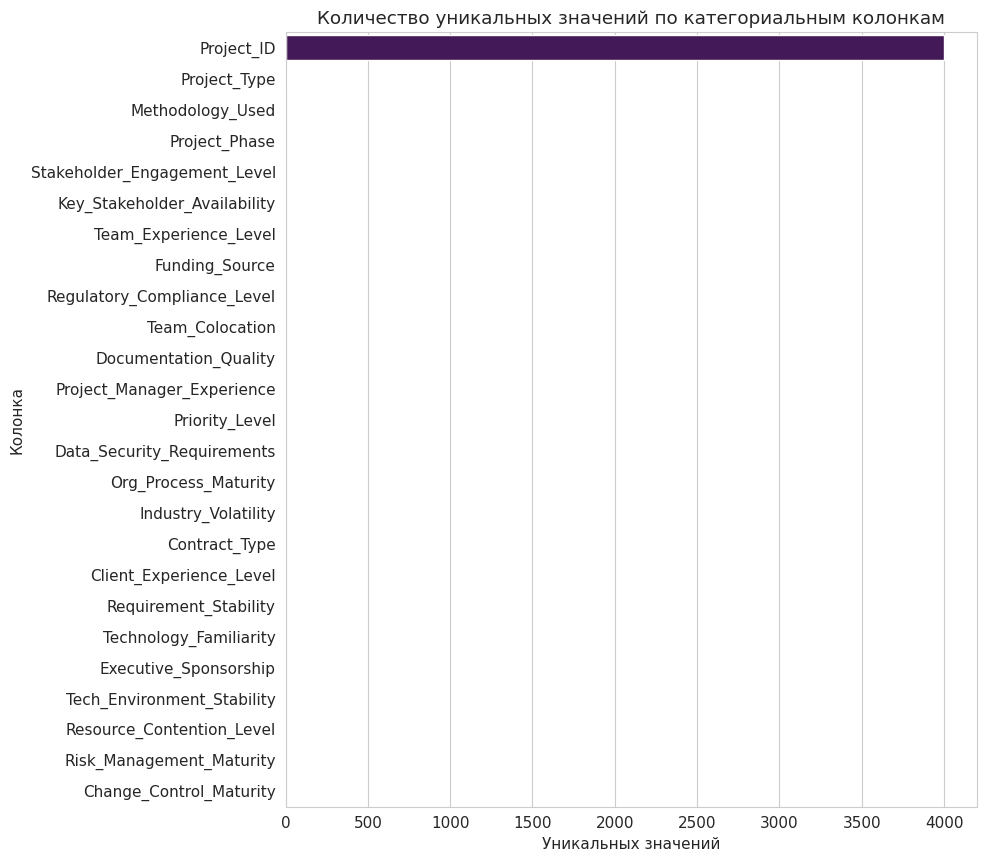

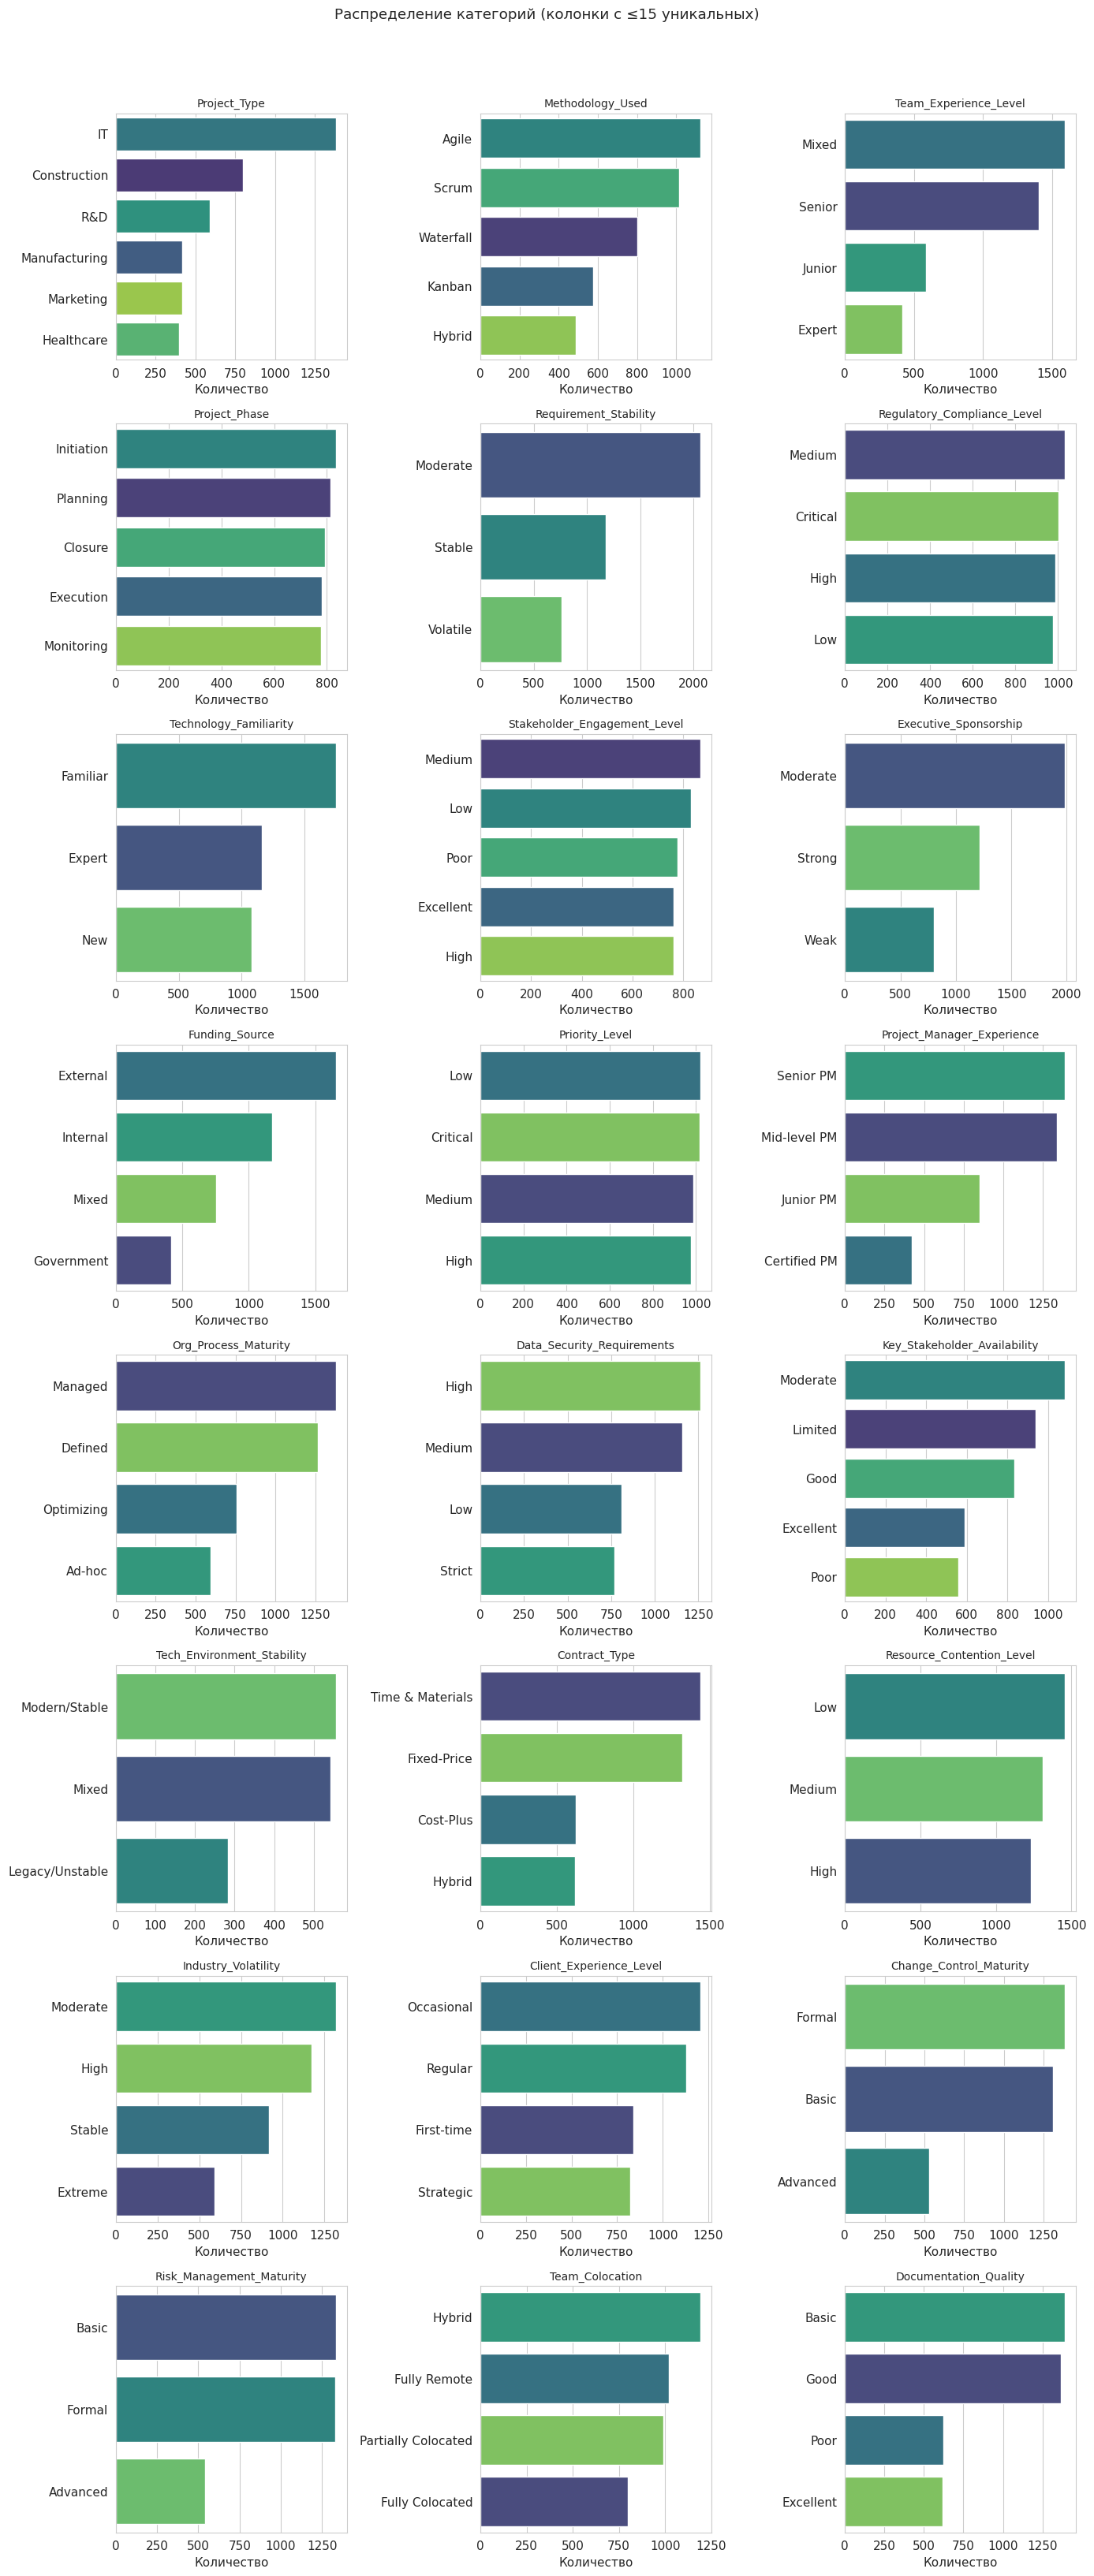

In [20]:
# 7.5: EDA — категориальные признаки
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
cat_cols = [c for c in cat_cols if c != "Risk_Level"]  # целевую не трогаем
print(f"Категориальных колонок (без целевой): {len(cat_cols)}")

if len(cat_cols) > 0:
    # Сводка: уникальные, пропуски, мода и её доля — этого хватает для решения о кодировании
    cat_summary = pd.DataFrame({
        "Уникальных": [df[c].nunique() for c in cat_cols],
        "Пропусков": [df[c].isna().sum() for c in cat_cols],
        "Мода": [df[c].mode().iloc[0] if df[c].notna().any() else None for c in cat_cols],
        "Доля моды, %": [(df[c].value_counts(normalize=True).iloc[0] * 100).round(2)
                          if df[c].notna().any() else None for c in cat_cols],
    }, index=cat_cols).sort_values("Уникальных", ascending=False)

    print("\nСводка по категориальным колонкам:")
    print(cat_summary.to_string())

    # Кардинальность по колонкам
    plt.figure(figsize=(10, max(4, len(cat_cols) * 0.35)))
    sns.barplot(x=cat_summary["Уникальных"], y=cat_summary.index,
                hue=cat_summary.index, palette="viridis", legend=False)
    plt.title("Количество уникальных значений по категориальным колонкам")
    plt.xlabel("Уникальных значений")
    plt.ylabel("Колонка")
    plt.tight_layout()
    plt.show()
    plt.close("all")

    # Распределение категорий — только для колонок с ≤15 уникальных
    low_card = [c for c in cat_cols if df[c].nunique() <= 15]
    if low_card:
        n = len(low_card)
        rows = (n + 2) // 3
        fig, axes = plt.subplots(rows, 3, figsize=(14, 4 * rows))
        axes = np.array(axes).flatten()
        for ax, col in zip(axes, low_card):
            order = df[col].value_counts().index
            sns.countplot(data=df, y=col, ax=ax, order=order,
                          hue=col, palette="viridis", legend=False)
            ax.set_title(col, fontsize=10)
            ax.set_xlabel("Количество")
            ax.set_ylabel("")
        for ax in axes[len(low_card):]:
            ax.axis("off")
        plt.suptitle("Распределение категорий (колонки с ≤15 уникальных)", y=1.02)
        plt.tight_layout()
        plt.show()
        plt.close("all")
else:
    print("Категориальных колонок нет.")

### 7.5. Категориальные признаки

**Что я построил:**
- Сводную таблицу по 25 категориальным колонкам (без целевой): количество уникальных значений, пропуски, мода и её доля.
- Столбчатую диаграмму кардинальности — сколько уникальных значений в каждой колонке.
- Распределение категорий (countplot) для колонок с ≤15 уникальными значениями.

**Что я вижу по кардинальности:**
- `Project_ID` — 4000 уникальных значений, по одному на каждый проект. Это идентификатор, а не признак. Удаляю до подачи в модель — иначе он даст только шум.
- Остальные 24 категориальных признака имеют **от 3 до 6 уникальных значений**. Низкая кардинальность — значит, кодирование будет простым и не раздует размерность.
- Колонок с высокой кардинальностью (десятки и сотни значений) нет. Можно обойтись One-Hot Encoding.

**По пропускам:** они только в трёх колонках — тех же, что я нашёл в 7.1. Решение уже принято: `Tech_Environment_Stability` удаляю, остальные обрабатываю на этапе предобработки.

**Что я вижу по распределению категорий:**
- Мода в большинстве колонок занимает 25–50% — выраженного перекоса в одну категорию нет.
- Исключение — `Requirement_Stability`, где мода (Moderate) занимает 51.6%. Но остальные 48% распределены между двумя другими категориями, так что признак остаётся информативным.

**Что это значит для проекта:**
- Категориальные признаки не создадут проблем с размерностью: 24 колонки по 3–6 значений — это около 100 бинарных признаков после One-Hot. Для 4000 строк это нормально.
- LightGBM умеет работать с категориальными признаками напрямую (через `categorical_feature`), но для чистоты пайплайна и совместимости с MLP я применю One-Hot.

**Мои решения:**
- `Project_ID` — удаляю.
- `Tech_Environment_Stability` — удаляю (65% пропусков).
- Остальные 23 категориальных признака — кодирую через One-Hot Encoding на этапе предобработки.
- Для LightGBM дополнительно проверю вариант с нативными категориальными признаками: возможно, даст лучший результат.

### 7.6. Выводы и решения по EDA

EDA позволил мне определить стратегию предобработки данных и зафиксировать ключевые решения для следующих этапов.

**Что я удаляю:**
- `Project_ID` — уникальный идентификатор, не несёт информации для модели.
- `Tech_Environment_Stability` — 65.5% пропусков. Заполнение исказит данные, польза от признака сомнительна.

**Что я оставляю без изменений:**
- Все числовые признаки (25 колонок). LightGBM устойчив к асимметрии и выбросам.
- Все категориальные признаки с низкой кардинальностью (3–6 значений) — их 23 колонки без учёта удалённых.

**Как я обрабатываю пропуски:**
- `Risk_Management_Maturity` (19.8%) и `Change_Control_Maturity` (19.5%) — оставляю как есть. LightGBM обработает пропуски автоматически. Для MLP заполню модой или отдельной категорией «Unknown».
- Все остальные колонки пропусков не имеют.

**Как я кодирую категориальные признаки:**
- One-Hot Encoding для всех 23 категориальных колонок. Это даст около 100 бинарных признаков — нормально для 4000 строк.
- Для LightGBM дополнительно проверю вариант с нативными категориальными признаками (`categorical_feature`). Если результат будет лучше, использую его.

**Что я делаю с мультиколлинеарностью:**
- На этом этапе ничего не удаляю. LightGBM справляется с коррелированными признаками.
- Вернусь к этому после SHAP-анализа: если важность «размажется» между связанными признаками, рассмотрю удаление одного из пары.

**Что я делаю с целевой переменной:**
- Четыре класса: Medium (34.9%), High (25.9%), Low (20.2%), Critical (19.1%). Дисбаланс умеренный.
- Основная метрика — F1-macro. Дополнительно смотрю ROC-AUC OvR.
- При обучении проверю, ловит ли модель класс Critical. Если нет — добавлю веса классов.

**Что я делаю с асимметрией и выбросами:**
- Для LightGBM — ничего. Деревья работают с рангами, а не с абсолютными значениями.
- Для MLP — проверю после масштабирования. Если выбросы будут мешать, применю робастное масштабирование.

**Что дальше:**
Перехожу к этапу 3 — предобработка и пайплайн. Собираю `ColumnTransformer` с One-Hot для категориальных и StandardScaler для числовых (для MLP). LightGBM буду обучать на сырых числовых признаках и One-Hot категориальных.

## 8. Предобработка и пайплайн

На этом этапе я превращаю сырые данные в формат, пригодный для обучения моделей. Решения приняты на основе EDA.

**Что я делаю по шагам:**

1. **Удаляю лишние колонки** — `Project_ID` и `Tech_Environment_Stability`. Первая не несёт информации, вторая имеет 65% пропусков.
2. **Разделяю данные** на признаки (`X`) и целевую переменную (`y`).
3. **Кодирую целевую переменную** — перевожу строковые метки (`Low`, `Medium`, `High`, `Critical`) в числа.
4. **Собираю `ColumnTransformer`** — для категориальных признаков применяю One-Hot Encoding, для числовых — StandardScaler (нужен для MLP, для LightGBM не обязателен, но не мешает).
5. **Оборачиваю всё в `Pipeline`** — чтобы предобработка и модель работали как единый объект. Это защищает от утечки данных при кросс-валидации.
6. **Разбиваю данные на train и test** — стратифицированно, чтобы пропорции классов сохранились в обеих выборках.
7. **Проверяю, что пайплайн работает** — обучаю на train, трансформирую test, смотрю на размерности.

**Зачем это нужно:**
- Единый пайплайн гарантирует, что преобразования применяются одинаково к train и test.
- Стратификация сохраняет баланс классов — важно для корректной оценки качества.
- Разделение данных позволяет честно проверить модель на данных, которых она не видела.

**Что смотрю в результате:**
- Размерности `X_train`, `X_test`, `y_train`, `y_test`.
- Распределение классов в train и test — должно быть одинаковым.
- Работает ли пайплайн без ошибок.

### 8.1 Подготовка данных: удаление лишнего и разделение на X/y

Убираю колонки, которые не несут полезной информации для модели:

- **`Project_ID`** — идентификатор, уникальный для каждой строки. Модель на нём только переобучится, и это утечка.
- **`Tech_Environment_Stability`** — удаляю по решению из EDA (либо почти константа, либо дублирует другой признак).

Дальше разделяю датасет: `X` — все признаки, `y` — целевая `Risk_Level`. Это стандартная подготовка перед кодированием и сборкой пайплайна.

In [21]:
# 8.1 Подготовка данных — удаление лишних колонок и разделение на X/y
# Колонки-идентификаторы и бесполезные для модели признаки
drop_cols = ["Project_ID", "Tech_Environment_Stability"]

# Удаляем только те, что реально есть в датасете (чтобы не упасть, если имени нет)
drop_cols = [c for c in drop_cols if c in df.columns]
print(f"Удаляю колонки: {drop_cols}")

df_clean = df.drop(columns=drop_cols)
print(f"Размер после удаления: {df_clean.shape[0]} строк, {df_clean.shape[1]} колонок")

# Разделяем признаки и целевую
X = df_clean.drop(columns=["Risk_Level"])
y = df_clean["Risk_Level"]

print(f"\nX: {X.shape}")
print(f"y: {y.shape}")
print(f"\nКлассы в y:\n{y.value_counts().to_string()}")

Удаляю колонки: ['Project_ID', 'Tech_Environment_Stability']
Размер после удаления: 4000 строк, 49 колонок

X: (4000, 48)
y: (4000,)

Классы в y:
Risk_Level
Medium      1396
High        1036
Low          806
Critical     762


### 8.1 Удаление лишних колонок, разделение X и y

**Что я сделал:**
- Удалил `Project_ID` (уникальный идентификатор) и `Tech_Environment_Stability` (65% пропусков).
- Разделил датасет на признаки (`X`) и целевую переменную (`y`).

**Что я вижу:**
- Размер после удаления: 4000 строк, 49 колонок.
- `X` имеет форму (4000, 48) — 48 признаков.
- `y` — вектор из 4000 меток.
- Классы в `y` распределены так: Medium — 1396, High — 1036, Low — 806, Critical — 762.

**Что это значит:**
- Размерность `X` соответствует ожиданиям: 51 исходная колонка минус `Project_ID`, минус `Tech_Environment_Stability`, минус целевая `Risk_Level` = 48 признаков.
- Распределение классов совпадает с тем, что я видел в EDA. Дисбаланс умеренный, стратификация при разбиении сохранит эти пропорции в train и test.
- Целевая переменная пока в строковом формате — её нужно закодировать числами перед обучением.

### 8.2 Кодирование целевой переменной

`Risk_Level` — строковая. Модели нужны числа. Использую `LabelEncoder`, чтобы получить целочисленные классы.

Важно: сохраняю соответствие «строка → число» отдельно, чтобы потом на графиках и в выводах показывать исходные названия, а не 0/1/2.

Если классов больше двух — задача многоклассовая, и метрики будут считаться по-другому (macro/weighted F1, ROC-AUC one-vs-rest).

In [22]:
# 8.2 Кодирование целевой переменной
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Сохраняю маппинг, чтобы потом возвращать исходные названия классов
class_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Соответствие классов:")
for name, code in class_mapping.items():
    print(f"  {name} → {code}")

print(f"\nРаспределение закодированной целевой:")
unique, counts = np.unique(y_encoded, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Класс {u}: {c} ({c / len(y_encoded) * 100:.2f}%)")

Соответствие классов:
  Critical → 0
  High → 1
  Low → 2
  Medium → 3

Распределение закодированной целевой:
  Класс 0: 762 (19.05%)
  Класс 1: 1036 (25.90%)
  Класс 2: 806 (20.15%)
  Класс 3: 1396 (34.90%)


### 8.2 Кодирование целевой переменной

**Что сделал:** применил `LabelEncoder` к `Risk_Level`.

**Что вижу:** классы закодированы в алфавитном порядке: Critical → 0, High → 1, Low → 2, Medium → 3. Распределение сохранилось: 762, 1036, 806, 1396. Пропорции те же, что и до кодирования.

**Что это значит:** для LightGBM и MLP порядок меток не важен — модели работают с ними как с категориями, а не как с числами на шкале. Если бы я использовал порядковую регрессию, пришлось бы задать порядок вручную (Low → 0, Medium → 1, High → 2, Critical → 3), но в нашем случае это не требуется.

### 8.3 Пайплайн: ColumnTransformer + Pipeline

Собираю препроцессинг в один объект, чтобы не делать преобразования руками и не ловить расхождения между train и test.

Что внутри:
- **числовые признаки** → `StandardScaler`. Деревья (LightGBM) к масштабу безразличны, но он нужен для MLP на этапе сравнения — так что готовим сразу;
- **категориальные** → `OneHotEncoder(handle_unknown="ignore")`. Игнор нужен, чтобы при появлении новой категории в test пайплайн не падал.

Оборачиваю всё в `Pipeline`. Дальше с ним можно работать как с обычной моделью: `.fit()` на train, `.transform()` на test. И в кросс-валидации он тоже поведёт себя корректно — препроцессинг будет пересчитываться на каждом фолде, без утечки.

In [24]:
# 8.3 Сборка препроцессинга — ColumnTransformer + Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Разделяю признаки по типу — уже после удаления ID-колонок
num_features = X.select_dtypes(include=np.number).columns.tolist()
cat_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

print(f"Числовых признаков: {len(num_features)}")
print(f"Категориальных признаков: {len(cat_features)}")
print(f"\nКатегориальные: {cat_features}")

# Препроцессинг: масштабирование числовых + one-hot для категориальных
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_features),
    ],
    remainder="drop"  # всё, что не попало в списки, отбрасываем
)

# Оборачиваю в Pipeline — пока только препроцессинг, модель добавим на следующем шаге
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
])

print("\nПайплайн собран. Шаги:")
print(pipeline.named_steps)

# Проверка размера после трансформации — сколько признаков получится на выходе
X_transformed = pipeline.fit_transform(X)
print(f"\nРазмер до трансформации: {X.shape}")
print(f"Размер после трансформации: {X_transformed.shape}")

Числовых признаков: 25
Категориальных признаков: 23

Категориальные: ['Project_Type', 'Methodology_Used', 'Team_Experience_Level', 'Project_Phase', 'Requirement_Stability', 'Regulatory_Compliance_Level', 'Technology_Familiarity', 'Stakeholder_Engagement_Level', 'Executive_Sponsorship', 'Funding_Source', 'Priority_Level', 'Project_Manager_Experience', 'Org_Process_Maturity', 'Data_Security_Requirements', 'Key_Stakeholder_Availability', 'Contract_Type', 'Resource_Contention_Level', 'Industry_Volatility', 'Client_Experience_Level', 'Change_Control_Maturity', 'Risk_Management_Maturity', 'Team_Colocation', 'Documentation_Quality']

Пайплайн собран. Шаги:
{'preprocessor': ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['Team_Size', 'Project_Budget_USD',
                                  'Estimated_Timeline_Months',
                                  'Complexity_Score', 'Stakeholder_Count',
                                  'Past_Similar_Projects',
 

### 8.3 Сборка пайплайна

**Что сделал:** собрал `ColumnTransformer` и обернул в `Pipeline`. Числовые признаки (25) → `StandardScaler`, категориальные (23) → `OneHotEncoder`.

**Что вижу:** до трансформации — 48 признаков, после — 119. One-Hot превратил 23 категориальных колонки в 94 бинарных, числовые 25 остались как есть. Матрица выросла в 2.5 раза.

**Что это значит:** 119 признаков на 4000 строк — нормально. Соотношение примерно 34 объекта на признак, переобучения из-за размерности быть не должно. Матрица плотная (4000×119 = ~476k значений), в память помещается без проблем.

### 8.4 Train/test split и проверка пайплайна

Разбиваю данные на обучающую и тестовую выборки — 80/20.

# Стратифицирую по целевой: пропорции классов в train и test должны совпадать. Если этого не сделать, при дисбалансе можно случайно получить тест, где почти нет редкого класса — метрики будут неинформативными.

`random_state` фиксирован, чтобы разбиение воспроизводилось.

Дальше — проверка, что пайплайн живой: обучаю препроцессинг только на train, трансформирую test. Всё, что было подогнано (медианы, средние, категории), берётся из train — иначе получим утечку.

In [25]:
# 8.4: Train/test split и проверка пайплайна
from sklearn.model_selection import train_test_split

# Стратифицированное разбиение — сохраняет пропорции классов
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=SEED
)

print(f"Train: {X_train.shape[0]} строк")
print(f"Test:  {X_test.shape[0]} строк")

# Проверяю, что пропорции классов сохранились
train_dist = pd.Series(y_train).value_counts(normalize=True).sort_index().round(4)
test_dist = pd.Series(y_test).value_counts(normalize=True).sort_index().round(4)

dist_df = pd.DataFrame({
    "Train, %": (train_dist * 100).round(2),
    "Test, %": (test_dist * 100).round(2),
})
print("\nРаспределение классов:")
print(dist_df.to_string())

# Проверка пайплайна: fit только на train, transform на test
pipeline.fit(X_train, y_train)
X_train_t = pipeline.transform(X_train)
X_test_t = pipeline.transform(X_test)

print(f"\nФорма после трансформации:")
print(f"  Train: {X_train_t.shape}")
print(f"  Test:  {X_test_t.shape}")

Train: 3200 строк
Test:  800 строк

Распределение классов:
   Train, %  Test, %
0     19.03    19.12
1     25.91    25.88
2     20.16    20.13
3     34.91    34.88

Форма после трансформации:
  Train: (3200, 119)
  Test:  (800, 119)


### 8.4. Train/test split

**Что сделал:** разбил данные на train (80%) и test (20%) со стратификацией по целевой переменной.

**Что вижу:** train — 3200 строк, test — 800. Пропорции классов сохранились: например, Critical — 19.03% в train и 19.12% в test, Medium — 34.91% и 34.88%. Разница в пределах 0.1 п.п. Форма после трансформации: train (3200, 119), test (800, 119).

**Что это значит:** стратификация сработала — обе выборки репрезентативны. Модель будет учиться на тех же пропорциях классов, что и тестироваться. Это важно для корректной оценки F1-macro: если бы класс Critical «провалился» в test, метрика была бы искажена.